# Student Performance Prediction

Predicts whether a student will pass or fail a module from their demographic
profile and their assessment/engagement activity **so far**, trained on the
OULAD dataset. The model is trained on point-in-course snapshots (10% / 25% /
40% / 55% / 70% / 85% / 100% of the way through a module) rather than only
complete-course totals, so it can be queried at any point in a live course
without misreading naturally-small early activity as a risk signal. It also
gets a rough trend signal -- clicks in the last 14 days vs. the full-so-far
total -- so a recently-declining student and a recently-improving one, with
the same lifetime totals, don't look identical to the model. The trained
pipeline produced at the end of this notebook is served by the
`/predict/performance` endpoint in `smart-elearning-api/`.


## 1. Load Data

In [8]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

sys.path.append(str(Path("smart-elearning-api").resolve()))

from student_risk.features import (
    RAW_INPUT_COLUMNS,
    CATEGORICAL_COLUMNS,
    add_row_features,
    compute_training_stats,
    build_features,
)
from student_risk.snapshots import CUTOFF_FRACTIONS, build_snapshot_table


`courses.csv` is loaded again here -- `module_presentation_length` is needed
to turn a course-progress fraction into a concrete day cutoff when building
point-in-course snapshots below. `studentAssessment` and `studentVle` are
kept at their raw, per-event granularity (not pre-aggregated here) since the
snapshot step filters events by date itself before aggregating.


In [9]:
DATA_DIR = Path("OULAD Dataset")

student_info = pd.read_csv(DATA_DIR / "studentInfo.csv")
student_reg = pd.read_csv(DATA_DIR / "studentRegistration.csv")
student_assess = pd.read_csv(DATA_DIR / "studentAssessment.csv")
student_vle = pd.read_csv(DATA_DIR / "studentVle.csv")
courses = pd.read_csv(DATA_DIR / "courses.csv")

print("Dataset shapes")
for name, df in {
    "student_info": student_info,
    "student_reg": student_reg,
    "student_assess": student_assess,
    "student_vle": student_vle,
    "courses": courses,
}.items():
    print(f"{name}: {df.shape}")


Dataset shapes
student_info: (32593, 12)
student_reg: (32593, 5)
student_assess: (173912, 5)
student_vle: (10655280, 6)
courses: (22, 3)


## 2. Handle Missing Values

`date_unregistration` is deliberately left as-is (`NaN` = never unregistered)
rather than filled with a sentinel here -- the snapshot step below needs to
tell "never unregistered" apart from "unregistered on day 0", which a `-1`
fill would collide with once it's compared against a day-based cutoff.
`vle.csv`, `assessments.csv` aren't loaded -- as before, nothing here uses
assessment weighting/type or VLE activity-type metadata.


In [10]:
student_info["imd_band"] = student_info["imd_band"].fillna(student_info["imd_band"].mode()[0])
student_reg["date_registration"] = student_reg["date_registration"].fillna(student_reg["date_registration"].median())
student_assess["score"] = student_assess["score"].fillna(0)


## 3. Create the Prediction Target

`target_pass` is the binary label the served model predicts. `target_cgpa`
is kept only for the supplementary regression comparison later in this
notebook -- it's the same `final_result` categories re-labeled as an ordinal
0-3 scale, not a real computed grade average, and it is not served by the
API.


In [11]:
student_info["target_pass"] = student_info["final_result"].map({
    "Pass": 1,
    "Distinction": 1,
    "Fail": 0,
    "Withdrawn": 0,
})

student_info["target_cgpa"] = student_info["final_result"].map({
    "Distinction": 3,
    "Pass": 2,
    "Fail": 1,
    "Withdrawn": 0,
})

student_info[["final_result", "target_pass", "target_cgpa"]].head()


,final_result,target_pass,target_cgpa
0,Pass,1,2
1,Pass,1,2
2,Withdrawn,0,0
3,Pass,1,2
4,Pass,1,2


## 4. Build Point-in-Course Snapshots

`build_snapshot_table()` (from `student_risk/snapshots.py`) turns each
student's full-course record into several rows -- one per cutoff fraction --
with assessment/VLE activity aggregated only from events on or before that
cutoff's day, and a temporally-safe `date_unregistration` (a student's
*eventual* withdrawal is never visible to an earlier snapshot). It also
computes `recent_clicks` -- clicks in the 14 days immediately before each
snapshot's cutoff, separate from the full-so-far `total_clicks` -- which
`student_risk.features` turns into `recent_click_share`, a rough trend
signal. See the module docstring for the exact rules.


In [12]:
demographic_columns = [
    "gender", "highest_education", "imd_band", "age_band",
    "num_of_prev_attempts", "studied_credits", "disability",
]

student_base = student_info[
    ["id_student", "code_module", "code_presentation", "target_pass", "target_cgpa"] + demographic_columns
].copy()

snapshot_df = build_snapshot_table(student_base, student_reg, student_assess, student_vle, courses, cutoffs=CUTOFF_FRACTIONS)

print("Snapshot rows:", snapshot_df.shape)
print("\nRows per elapsed_fraction bucket:")
print(snapshot_df["elapsed_fraction"].value_counts().sort_index())


Snapshot rows: (228151, 20)

Rows per elapsed_fraction bucket:
elapsed_fraction
0.10    32593
0.25    32593
0.40    32593
0.55    32593
0.70    32593
0.85    32593
1.00    32593
Name: count, dtype: int64


## 5. Select Modeling Columns

`code_module`/`code_presentation` are carried along for later auditability
only -- as before, they're never passed into `build_features()` and never
reach the model.


In [13]:
raw_columns = (
    ["id_student", "code_module", "code_presentation", "target_pass", "target_cgpa"]
    + RAW_INPUT_COLUMNS
)
model_base = snapshot_df[raw_columns].copy()
model_base.head()


,id_student,code_module,code_presentation,target_pass,target_cgpa,gender,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,total_score,avg_score,num_assessments,total_clicks,recent_clicks,date_registration,date_unregistration,elapsed_fraction
0,11391,AAA,2013J,1,2,M,HE Qualification,90-100%,55<=,0,240,N,78.0,78.0,1.0,401.0,100.0,-159.0,-1.0,0.1
1,28400,AAA,2013J,1,2,F,HE Qualification,20-30%,35-55,0,60,N,70.0,70.0,1.0,550.0,94.0,-53.0,-1.0,0.1
2,30268,AAA,2013J,0,0,F,A Level or Equivalent,30-40%,35-55,0,60,Y,0.0,0.0,0.0,281.0,0.0,-92.0,12.0,0.1
3,31604,AAA,2013J,1,2,F,A Level or Equivalent,50-60%,35-55,0,60,N,72.0,72.0,1.0,478.0,139.0,-52.0,-1.0,0.1
4,32885,AAA,2013J,1,2,F,Lower Than A Level,50-60%,0-35,0,60,N,69.0,69.0,1.0,567.0,126.0,-176.0,-1.0,0.1


## 6. Train/Test Split

Each student now contributes up to 7 rows (one per cutoff). Splitting by row
would let the same student's early snapshot land in train and their late
snapshot land in test, leaking that student's identity/outcome across the
split -- so the split happens on `id_student` first, and every row for a
given student follows their student ID to the same side.


In [14]:
from sklearn.model_selection import train_test_split

student_target = model_base.groupby("id_student")["target_pass"].first()

train_ids, test_ids = train_test_split(
    student_target.index, test_size=0.2, random_state=42, stratify=student_target.values
)

train_mask = model_base["id_student"].isin(train_ids)

X = model_base.drop(columns=["target_pass", "target_cgpa"])
y_class = model_base["target_pass"]
y_reg = model_base["target_cgpa"]

X_train, X_test = X[train_mask].copy(), X[~train_mask].copy()
y_train_class, y_test_class = y_class[train_mask].copy(), y_class[~train_mask].copy()
y_train_reg, y_test_reg = y_reg[train_mask].copy(), y_reg[~train_mask].copy()

print("Train rows:", X_train.shape, "Test rows:", X_test.shape)
print("Unique students -- train:", X_train["id_student"].nunique(), "test:", X_test["id_student"].nunique())


Train rows: (182539, 18) Test rows: (45612, 18)
Unique students -- train: 23028 test: 5757


## 7. Training-Set Feature Statistics

`total_clicks` at 10% into a course is naturally far smaller than at 100% --
pooling all snapshots into one global average would make every early
snapshot look like "low activity" regardless of whether the student is
actually behind their own-stage peers. Statistics are computed **per
elapsed_fraction bucket**, from `X_train` only.


In [15]:
train_stats = compute_training_stats(add_row_features(X_train), CUTOFF_FRACTIONS)

print("Cutoffs:", train_stats["cutoffs"])
print("Rows per bucket:", {k: v["row_count"] for k, v in train_stats["by_cutoff"].items()})


Cutoffs: [0.1, 0.25, 0.4, 0.55, 0.7, 0.85, 1.0]
Rows per bucket: {'0.1': 26077, '0.25': 26077, '0.4': 26077, '0.55': 26077, '0.7': 26077, '0.85': 26077, '1.0': 26077}


## 8. Model-Ready Feature Tables

`build_features()` -- the same function `smart-elearning-api` calls at
serving time -- is applied separately to `X_train` and `X_test`, both using
`train_stats`, so the test set never contributes to the statistics its own
features are computed from. Each row is matched to its nearest trained
elapsed_fraction bucket.


In [16]:
X_train_features = build_features(X_train, train_stats)
X_test_features = build_features(X_test, train_stats)

print("Modeling feature columns:", list(X_train_features.columns))
X_train_features.head()


Modeling feature columns: ['gender_m', 'edu_level', 'imd_num', 'age_num', 'num_of_prev_attempts', 'studied_credits', 'disability_flag', 'total_score', 'avg_score', 'num_assessments', 'total_clicks', 'recent_clicks', 'recent_click_share', 'elapsed_fraction', 'registration_lead_days', 'withdrawn_by_snapshot_flag', 'registration_duration', 'clicks_per_credit', 'score_per_assess', 'assessment_density', 'score_per_credit', 'activity_efficiency', 'credit_load_category', 'engagement_intensity', 'low_activity_flag', 'late_registration_flag', 'high_click_but_low_score_flag']


,gender_m,edu_level,imd_num,age_num,num_of_prev_attempts,studied_credits,disability_flag,total_score,avg_score,num_assessments,total_clicks,recent_clicks,recent_click_share,elapsed_fraction,registration_lead_days,withdrawn_by_snapshot_flag,registration_duration,clicks_per_credit,score_per_assess,assessment_density,score_per_credit,activity_efficiency,credit_load_category,engagement_intensity,low_activity_flag,late_registration_flag,high_click_but_low_score_flag
0,1,3,95.0,60.0,0,240,0,78.0,78.0,1.0,401.0,100.0,0.249377,0.1,159.0,0,-1.0,1.670833,78.0,0.004167,0.325000,46.683292,NaN,0.282282,0,0,0
1,0,3,25.0,45.0,0,60,0,70.0,70.0,1.0,550.0,94.0,0.170909,0.1,53.0,0,-1.0,9.166667,70.0,0.016667,1.166667,7.636364,light,0.667811,0,1,0
2,0,2,35.0,45.0,0,60,1,0.0,0.0,0.0,281.0,0.0,0.000000,0.1,92.0,1,104.0,4.683333,0.0,0.000000,0.000000,0.000000,light,-0.028211,0,0,1
3,0,2,55.0,45.0,0,60,0,72.0,72.0,1.0,478.0,139.0,0.290795,0.1,52.0,0,-1.0,7.966667,72.0,0.016667,1.200000,9.037657,light,0.481515,0,1,0
4,0,1,55.0,17.5,0,60,0,69.0,69.0,1.0,567.0,126.0,0.222222,0.1,176.0,0,-1.0,9.450000,69.0,0.016667,1.150000,7.301587,light,0.711797,0,0,0


## 9. Preprocessing Pipeline

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


def make_preprocessor():
    # A fresh, unfit ColumnTransformer per pipeline so each model in the
    # comparison below fits its own encoder on X_train only.
    # sparse_output=False: GaussianNB (below) can't accept a sparse matrix,
    # and the API only ever scores one row at a time, where dense is simpler.
    return ColumnTransformer(
        transformers=[
            ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL_COLUMNS)
        ],
        remainder="passthrough",
    )


## 10. Classification Model Comparison

Eight classifiers, each wrapped in its own `Pipeline(preprocessor, model)`,
trained on `X_train_features` and evaluated on the held-out `X_test_features`.


In [18]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

classification_models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=200, learning_rate=0.8, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "XGBoost": XGBClassifier(random_state=42, eval_metric="logloss"),
}

classification_results = []
fitted_classification_pipelines = {}

for name, model in classification_models.items():
    pipeline = Pipeline([("preprocessor", make_preprocessor()), ("model", model)])
    pipeline.fit(X_train_features, y_train_class)
    fitted_classification_pipelines[name] = pipeline

    y_pred = pipeline.predict(X_test_features)
    classification_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test_class, y_pred),
        "Precision": precision_score(y_test_class, y_pred),
        "Recall": recall_score(y_test_class, y_pred),
        "F1-score": f1_score(y_test_class, y_pred),
    })

classification_comparison = pd.DataFrame(classification_results).sort_values("Accuracy", ascending=False)
classification_comparison


,Model,Accuracy,Precision,Recall,F1-score
5,XGBoost,0.851004,0.815948,0.886609,0.849812
1,Random Forest,0.846926,0.808882,0.887808,0.846509
2,Gradient Boosting,0.846225,0.810007,0.883888,0.845336
3,AdaBoost,0.830659,0.806857,0.846445,0.826177
0,Logistic Regression,0.820310,0.790207,0.846906,0.817575
4,KNN,0.795295,0.755535,0.841833,0.796353


## 11. Select and Evaluate the Best Classifier

Whichever model ranks first by accuracy above is the one that gets saved and
served -- not a hardcoded choice, so re-running this notebook with different
data or models will still save whichever pipeline actually wins.


In [19]:
best_model_name = classification_comparison.iloc[0]["Model"]
best_pipeline = fitted_classification_pipelines[best_model_name]

print(f"Best classifier: {best_model_name}")

y_pred_best = best_pipeline.predict(X_test_features)
print(classification_report(y_test_class, y_pred_best))


Best classifier: XGBoost
              precision    recall  f1-score   support

           0       0.89      0.82      0.85     23926
           1       0.82      0.89      0.85     21686

    accuracy                           0.85     45612
   macro avg       0.85      0.85      0.85     45612
weighted avg       0.85      0.85      0.85     45612



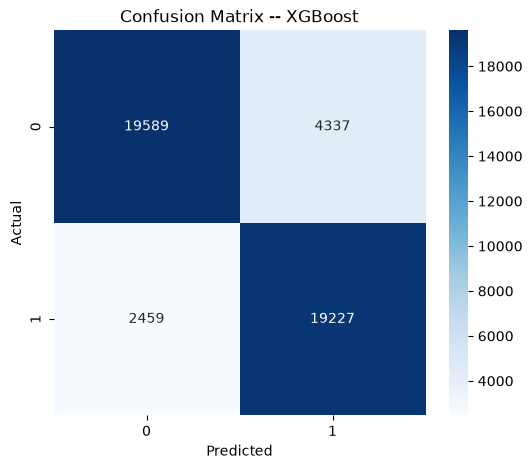

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test_class, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix -- {best_model_name}")
plt.show()


## 12. Save the Trained Pipeline

Saves the full pipeline (encoder + model), the per-cutoff-bucket training
statistics `build_features()` needs, and the exact feature-column list and
cutoff list the pipeline was fit on -- `smart-elearning-api` validates
against the feature list at startup so a drift between this notebook and the
API fails loudly instead of silently.


In [21]:
import json
from datetime import datetime, timezone

import joblib

MODELS_DIR = Path("smart-elearning-api/models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(best_pipeline, MODELS_DIR / "pass_fail_pipeline.pkl")

with open(MODELS_DIR / "feature_stats.json", "w", encoding="utf-8") as f:
    json.dump(train_stats, f, indent=2)

best_metrics = classification_comparison.loc[
    classification_comparison["Model"] == best_model_name
].iloc[0]

metadata = {
    "model_name": best_model_name,
    "feature_columns": list(X_train_features.columns),
    "categorical_columns": CATEGORICAL_COLUMNS,
    "cutoffs": CUTOFF_FRACTIONS,
    # cast to native float -- numpy float64 isn't JSON-serializable
    "metrics": {k: float(v) for k, v in best_metrics.items() if k != "Model"},
    "trained_at": datetime.now(timezone.utc).isoformat(),
}
with open(MODELS_DIR / "metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print("Saved pipeline, feature_stats.json, and metadata.json to", MODELS_DIR)


Saved pipeline, feature_stats.json, and metadata.json to smart-elearning-api\models
